In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vaibhavsxn/google-stock-prices-training-and-test-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/google-stock-prices-training-and-test-data


In [88]:
#Loading the training data 
import pandas as pd
df = pd.read_csv('/kaggle/input/google-stock-prices-training-and-test-data/Google_Stock_Price_Train.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [89]:
#making sure there's no comma in the close column
df['Close'] = df['Close'].str.replace(',','').astype(float)


In [90]:
train_set = df.iloc[:,4:5].values
train_set

array([[663.59],
       [666.45],
       [657.21],
       ...,
       [785.05],
       [782.79],
       [771.82]])

In [91]:
#scaling 
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
train_set = sc.fit_transform(train_set)
train_set

array([[0.23757287],
       [0.24151427],
       [0.22878051],
       ...,
       [0.40495845],
       [0.40184391],
       [0.38672602]])

In [92]:
#the number of records in the train_Set
len(train_set)

1258

In [93]:
#Price existing tommorow will be the price for today
X_train = train_set[0:1257]
y_train = train_set[1:1258]



In [94]:
X_train,y_train

(array([[0.23757287],
        [0.24151427],
        [0.22878051],
        ...,
        [0.41391618],
        [0.40495845],
        [0.40184391]]),
 array([[0.24151427],
        [0.22878051],
        [0.21641884],
        ...,
        [0.40495845],
        [0.40184391],
        [0.38672602]]))

In [95]:
#Since RNN model expects 3D data we need to convert the 2D into 3D by adding TImestep:the frequency of data: 1day
import numpy as np

X_train = np.reshape(X_train,(1257,1,1))


In [96]:
X_train

array([[[0.23757287]],

       [[0.24151427]],

       [[0.22878051]],

       ...,

       [[0.41391618]],

       [[0.40495845]],

       [[0.40184391]]])

In [97]:
#inintializing the RNN model
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense

model = Sequential([
    LSTM(units=50,return_sequences=False,input_shape=(1,1)),
    Dropout(0.2),
    Dense(1,activation='linear')
    
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [98]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
#compiling the model 
model.compile(loss='mse',optimizer='adam',metrics=['mae'])

In [101]:
#Training the model
history = model.fit(X_train,y_train,batch_size= 15,epochs=100,validation_split = 0.05,verbose=2,shuffle=False)

Epoch 1/100
80/80 - 2s - 20ms/step - loss: 0.0783 - mae: 0.2128 - val_loss: 0.0243 - val_mae: 0.1547
Epoch 2/100
80/80 - 0s - 5ms/step - loss: 0.0402 - mae: 0.1544 - val_loss: 0.0063 - val_mae: 0.0774
Epoch 3/100
80/80 - 0s - 5ms/step - loss: 0.0310 - mae: 0.1410 - val_loss: 0.0042 - val_mae: 0.0626
Epoch 4/100
80/80 - 0s - 5ms/step - loss: 0.0238 - mae: 0.1241 - val_loss: 0.0029 - val_mae: 0.0518
Epoch 5/100
80/80 - 0s - 5ms/step - loss: 0.0184 - mae: 0.1095 - val_loss: 0.0021 - val_mae: 0.0435
Epoch 6/100
80/80 - 0s - 5ms/step - loss: 0.0122 - mae: 0.0895 - val_loss: 0.0014 - val_mae: 0.0358
Epoch 7/100
80/80 - 0s - 5ms/step - loss: 0.0074 - mae: 0.0691 - val_loss: 0.0012 - val_mae: 0.0320
Epoch 8/100
80/80 - 0s - 5ms/step - loss: 0.0045 - mae: 0.0512 - val_loss: 7.5087e-04 - val_mae: 0.0253
Epoch 9/100
80/80 - 0s - 5ms/step - loss: 0.0031 - mae: 0.0407 - val_loss: 4.9109e-04 - val_mae: 0.0197
Epoch 10/100
80/80 - 0s - 5ms/step - loss: 0.0021 - mae: 0.0313 - val_loss: 4.1431e-04 - va

In [103]:
print("sample preds (first 6):",
      sc.inverse_transform(model.predict(X_train[:6]).reshape(-1,1)).flatten())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
sample preds (first 6): [666.2368  669.03937 659.98413 651.19116 624.24207 624.89923]


In [104]:
#Testing on test data
test_set = pd.read_csv('/kaggle/input/google-stock-prices-training-and-test-data/Google_Stock_Price_Test.csv')
test_set

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"
5,1/10/2017,807.86,809.13,803.51,804.79,"1,176,800"
6,1/11/2017,805.00,808.15,801.37,807.91,"1,065,900"
7,1/12/2017,807.14,807.39,799.17,806.36,"1,353,100"
8,1/13/2017,807.48,811.22,806.69,807.88,"1,099,200"
9,1/17/2017,807.08,807.14,800.37,804.61,"1,362,100"


In [105]:
test_set = test_set.iloc[:,4:5]
test_set

,Close
0,786.14
1,786.90
2,794.02
3,806.15
4,806.65
5,804.79
6,807.91
7,806.36
8,807.88
9,804.61


In [106]:
#Scaling the test data
inputs = sc.transform(test_set)
inputs

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


array([[0.40646059],
       [0.40750796],
       [0.41732012],
       [0.43403663],
       [0.43472569],
       [0.4321624 ],
       [0.43646211],
       [0.43432603],
       [0.43642077],
       [0.43191434],
       [0.43392638],
       [0.42855174],
       [0.43247936],
       [0.45217259],
       [0.45845679],
       [0.47471852],
       [0.46986756],
       [0.45768505],
       [0.42875846],
       [0.42113749]])

In [107]:
#tranforming into 3D
inputs = np.reshape(inputs,(20,1,1))
inputs

array([[[0.40646059]],

       [[0.40750796]],

       [[0.41732012]],

       [[0.43403663]],

       [[0.43472569]],

       [[0.4321624 ]],

       [[0.43646211]],

       [[0.43432603]],

       [[0.43642077]],

       [[0.43191434]],

       [[0.43392638]],

       [[0.42855174]],

       [[0.43247936]],

       [[0.45217259]],

       [[0.45845679]],

       [[0.47471852]],

       [[0.46986756]],

       [[0.45768505]],

       [[0.42875846]],

       [[0.42113749]]])

In [109]:
#Predicting hte values
predicted_values = model.predict(inputs)
predicted_values

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.40623662],
       [0.40725595],
       [0.4168024 ],
       [0.4330532 ],
       [0.43372267],
       [0.43123204],
       [0.43540972],
       [0.43333438],
       [0.43536952],
       [0.43099093],
       [0.4329461 ],
       [0.42772293],
       [0.43154   ],
       [0.45066446],
       [0.4567619 ],
       [0.47252813],
       [0.46782684],
       [0.4560132 ],
       [0.42792392],
       [0.42051488]], dtype=float32)

In [110]:
predicted_values = np.reshape(predicted_values,(20,1))
predicted_values

array([[0.40623662],
       [0.40725595],
       [0.4168024 ],
       [0.4330532 ],
       [0.43372267],
       [0.43123204],
       [0.43540972],
       [0.43333438],
       [0.43536952],
       [0.43099093],
       [0.4329461 ],
       [0.42772293],
       [0.43154   ],
       [0.45066446],
       [0.4567619 ],
       [0.47252813],
       [0.46782684],
       [0.4560132 ],
       [0.42792392],
       [0.42051488]], dtype=float32)

In [111]:
#Reshaping the output
test_pred = sc.inverse_transform(predicted_values)
test_pred

array([[785.9775 ],
       [786.71716],
       [793.64435],
       [805.4364 ],
       [805.92224],
       [804.1149 ],
       [807.14636],
       [805.6404 ],
       [807.1171 ],
       [803.93994],
       [805.35864],
       [801.5686 ],
       [804.3384 ],
       [818.2157 ],
       [822.64014],
       [834.08057],
       [830.6692 ],
       [822.09686],
       [801.7144 ],
       [796.33826]], dtype=float32)

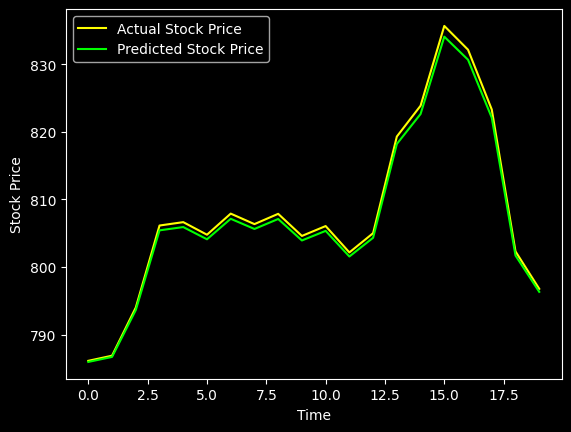

In [112]:
import matplotlib.pyplot as plt
plt.plot(test_set,color='yellow',label='Actual Stock Price')
plt.plot(test_pred,color='lime',label='Predicted Stock Price')
plt.xlabel("Time")
plt.ylabel('Stock Price')
plt.legend()
plt.style.use('dark_background')
plt.show()


In [113]:
model.save('my_model.keras')

In [114]:
#Importing the model
from keras.models import load_model
saved_model = load_model('my_model.keras')

In [126]:
#Predicting next day stock price
today_price = float(input("Enter today's stock price:"))

Enter today's stock price: 800


In [127]:

today_scaled = sc.transform(np.array([[today_price]]))
today_input = today_scaled.reshape(1,1,1)
result_scaled = model.predict(today_input)
tomorrow_price = sc.inverse_transform(result_scaled)[0][0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [85]:
print(sc.data_min_, sc.data_max_)

[491.2] [1216.83]


In [128]:
if today_price < sc.data_min_ or today_price > sc.data_max_:
    print("Warning: input is outside training range, prediction may be unstable.")
else:
    print(f"Tomorrow Stock Price Predicted as: {tomorrow_price:.2f}")

Tomorrow Stock Price Predicted as: 799.46
